/home/kdg/anaconda3/envs/r2c/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Overall average: 2.8299388888888912
Number of clusters: 5
Total number of elements: 1800
Cluster 3 - Elements: 421, Average creativity score: 2.05
Cluster 2 - Elements: 412, Average creativity score: 2.77
Cluster 1 - Elements: 471, Average creativity score: 2.98
Cluster 0 - Elements: 295, Average creativity score: 3.25
Cluster 4 - Elements: 201, Average creativity score: 3.62

Variances: [1723.4011995922901, 469.1345385517792, 453.4420204840818, 1143.925294037102, 1258.901405393239] 


convenctional cluster: Cluster 1



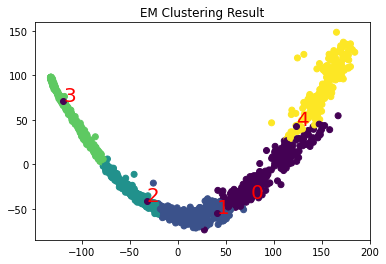

In [ ]:
import torch
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
import csv
from collections import Counter

# EM Clustering --------------------------------------------------------------------------------------------------------
# Load data
f = open('../datasets/D1.csv', 'r', encoding="UTF-8")
reader = csv.reader(f)
cnt = 0
docs = []
scores = []
for line in reader:
    if cnt != 0:
        docs.append(line[1])
        scores.append(line[11])
    else:
        cnt += 1
docs = np.array(docs)
scores = list(map(float, scores))

print('Overall average:', sum(scores)/len(scores))

# Load pre-computed embeddings
data = torch.load('../cache/D1_e2v_2d.pt')

# Set number of clusters and fit Gaussian Mixture Model
K = 5
model = GaussianMixture(K, random_state=0)
model.fit(data)

# Check estimated number of clusters
estimated_n_clusters = model.n_components
print('Number of clusters:', estimated_n_clusters)

# Get cluster assignments
labels = model.predict(data)

# Calculate sum of scores per cluster
my_dict = {key: float(0) for key in range(K)}
for label, score in zip(labels, scores):
    my_dict[label] += score

# Count elements per cluster
print('Total number of elements:', len(labels))
unique_elements, counts = np.unique(labels, return_counts=True)
cnt = []
for element, count in zip(unique_elements, counts):
    cnt.append(count)

# Visualize clustering result
plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.title('EM Clustering Result')

# Calculate average creativity score per cluster
avg = []
for i in range(K):
    avg.append(round(my_dict[i] / cnt[i], 2))
avg = np.array(avg)

# Print cluster statistics sorted by average score
for i in avg.argsort():
    print(f'Cluster {i} - Elements: {cnt[i]}, Average creativity score: {avg[i]}')

# Calculate cluster variances
unique_labels, indices = np.unique(labels, return_index=True)
cluster_variances = model.covariances_
cluster_variances = [np.trace(covariance_matrix) for covariance_matrix in cluster_variances]
print('\nVariances:', cluster_variances, '\n')

# Find conventional cluster
counts = Counter(labels)
max_index, _ = counts.most_common(1)[0]
print(f'\nconventional cluster: Cluster {max_index}\n')

# Get indices of other clusters
other_idx = [i for i in range(len(cnt)) if i != max_index]

# Get cluster means and probabilities
avg_vectors = model.means_
essay_cluster_prob = model.predict_proba(data)

# Annotate cluster centers on plot
for label, index in zip(unique_labels, indices):
    plt.scatter(data[index, 0], data[index, 1], c=label)
    plt.annotate(label, (data[index, 0], data[index, 1]), color='red', size=20)
plt.show()